In [1]:
import pandas as pd

df=pd.read_csv("spotify_data_cleaned.csv")
df=df.sample(n=5000,random_state=42).reset_index(drop=True)
df.head()

,Unnamed: 0,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,instrumentalness,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo
0,116368,0.910,1977,0.500,['Idris Muhammad'],0.894,273067,0.5210,0,0KdzyvsBqX1HV3uLxGm2JV,0.772,4,0.068,-7.048,1,Camby Bolongo,34,1977,0.0847,126.805
1,161935,0.583,1976,0.930,['Stan Getz'],0.585,182200,0.2720,0,1f4eO5waC6glPLXUhYKLm2,0.115,11,0.128,-16.693,0,Just One of Those Things,26,1976,0.0802,90.104
2,135703,0.647,1994,0.157,"['Warren G', 'The Twinz']",0.878,179933,0.5200,1,1X07ZfF5KQt8dyJ5kAkVAQ,0.000,7,0.173,-12.609,1,Recognize,38,1994-06-07,0.4030,90.744
3,112288,0.196,1957,0.937,['Red Garland Quintet'],0.463,925947,0.2870,0,5wmMDeM4qvLfwqLa2cvoks,0.837,0,0.112,-11.758,0,Soul Junction,13,1957,0.0363,186.764
4,22,0.422,1921,0.995,['Ignacio Corsini'],0.648,154240,0.0995,0,0SK1upzAP6NvIgF0uGh6z2,0.846,11,0.112,-22.429,1,Flor Marchita - Remasterizado,0,1921-03-20,0.1050,71.978


In [2]:
#Select relevant numerical features for clustering
from sklearn.preprocessing import StandardScaler

numerical_features = [
    "valence","danceability","energy","tempo","acousticness","liveness","speechiness","instrumentalness"
]

scaler=StandardScaler()
df_scaled=pd.DataFrame(scaler.fit_transform(df[numerical_features]),columns=numerical_features)
df_scaled

,valence,danceability,energy,tempo,acousticness,liveness,speechiness,instrumentalness
0,1.473178,2.032267,0.142150,0.310507,-0.005840,-0.783298,-0.107375,1.916073
1,0.226049,0.276101,-0.771789,-0.886487,1.126217,-0.446557,-0.133457,-0.171477
2,0.470135,1.941333,0.138480,-0.865614,-0.908852,-0.194001,1.737477,-0.536877
3,-1.249911,-0.417272,-0.716732,2.266056,1.144646,-0.536354,-0.387900,2.122604
4,-0.387981,0.634154,-1.404939,-1.477663,1.297342,-0.536354,0.010283,2.151200
...,...,...,...,...,...,...,...,...
4995,0.336651,-0.019435,0.810170,0.374302,-0.837769,-0.598090,-0.353124,-0.536877
4996,1.507503,1.009258,1.357065,-0.824128,-1.106567,0.434583,-0.270821,-0.536877
4997,-0.681647,-1.826752,-0.599278,-2.003804,0.999848,0.114678,-0.387900,-0.536835
4998,-0.906665,-0.815109,-1.495966,-0.516212,1.284178,-0.592478,-0.412243,-0.287769


In [3]:
#Train Test Split
from sklearn.model_selection import train_test_split
train_data, test_data=train_test_split(df_scaled,test_size=0.2,random_state=42)

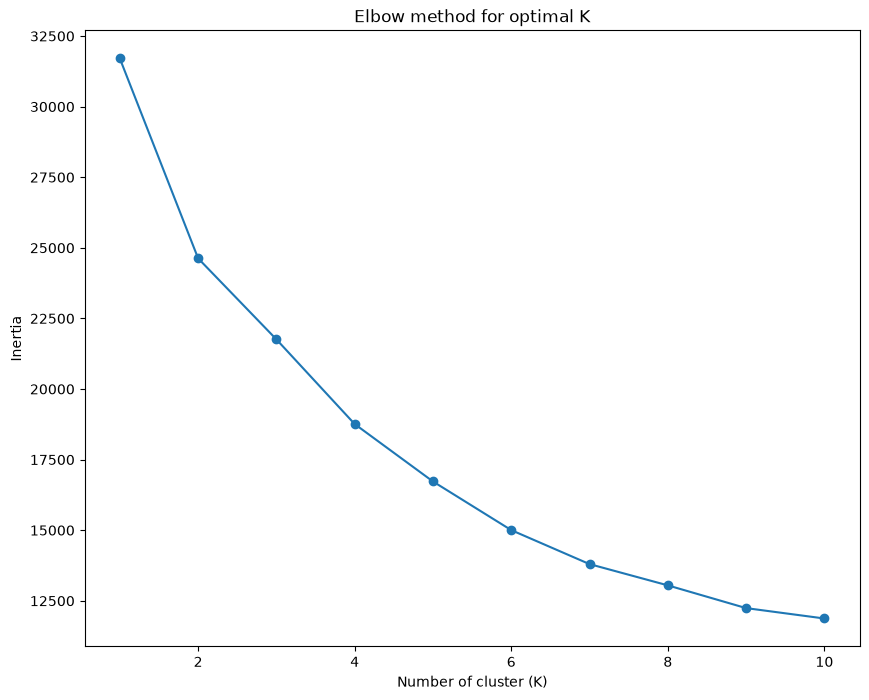

In [4]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia=[]
k_values=range(1,11)

for k in k_values:
    kmeans= KMeans(n_clusters=k, random_state=42)
    kmeans.fit(train_data)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10,8))
plt.plot(k_values,inertia,marker='o')
plt.xlabel("Number of cluster (K)")
plt.ylabel("Inertia")
plt.title("Elbow method for optimal K")
plt.show()

In [5]:
optimal_k = 5
kmeans=KMeans(n_clusters=optimal_k,random_state=42)
df["Cluster"]=kmeans.fit_predict(df_scaled)

In [6]:
df

,Unnamed: 0,valence,year,acousticness,artists,danceability,duration_ms,energy,explicit,id,...,key,liveness,loudness,mode,name,popularity,release_date,speechiness,tempo,Cluster
0,116368,0.910,1977,0.5000,['Idris Muhammad'],0.894,273067,0.5210,0,0KdzyvsBqX1HV3uLxGm2JV,...,4,0.068,-7.048,1,Camby Bolongo,34,1977,0.0847,126.805,1
1,161935,0.583,1976,0.9300,['Stan Getz'],0.585,182200,0.2720,0,1f4eO5waC6glPLXUhYKLm2,...,11,0.128,-16.693,0,Just One of Those Things,26,1976,0.0802,90.104,0
2,135703,0.647,1994,0.1570,"['Warren G', 'The Twinz']",0.878,179933,0.5200,1,1X07ZfF5KQt8dyJ5kAkVAQ,...,7,0.173,-12.609,1,Recognize,38,1994-06-07,0.4030,90.744,1
3,112288,0.196,1957,0.9370,['Red Garland Quintet'],0.463,925947,0.2870,0,5wmMDeM4qvLfwqLa2cvoks,...,0,0.112,-11.758,0,Soul Junction,13,1957,0.0363,186.764,2
4,22,0.422,1921,0.9950,['Ignacio Corsini'],0.648,154240,0.0995,0,0SK1upzAP6NvIgF0uGh6z2,...,11,0.112,-22.429,1,Flor Marchita - Remasterizado,0,1921-03-20,0.1050,71.978,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,121224,0.612,2001,0.1840,['Alice Cooper'],0.533,186093,0.7030,0,5LY8GsHfU7G6tmeXxStEb6,...,2,0.101,-6.364,1,No More Mr. Nice Guy - 2002 Remaster,42,2001,0.0423,128.761,1
4996,166328,0.919,1999,0.0819,['Britney Spears'],0.714,200467,0.8520,0,6039GmVngyHmWfOuWOhjCK,...,8,0.285,-6.570,1,Soda Pop,40,1999-01-12,0.0565,92.016,1
4997,121731,0.345,2012,0.8820,['Issa Ibrahim'],0.215,167741,0.3190,0,4UuMkQLjxSgcrW2d1zFIJT,...,0,0.228,-12.845,1,Susan,0,2012-09-03,0.0363,55.846,2
4998,59641,0.286,1942,0.9900,"['Felix Mendelssohn', 'Paul Robeson Jr.', 'Law...",0.393,187267,0.0747,0,2rRxJzTQyvm5Wwj9ObnZvv,...,10,0.102,-17.930,1,"The Lord God of Abraham, from Elijah, Op. 70",0,1942,0.0321,101.457,2


In [7]:
df['Cluster'].value_counts()

Cluster
1    1371
0    1369
4    1104
2     948
3     208
Name: count, dtype: int64

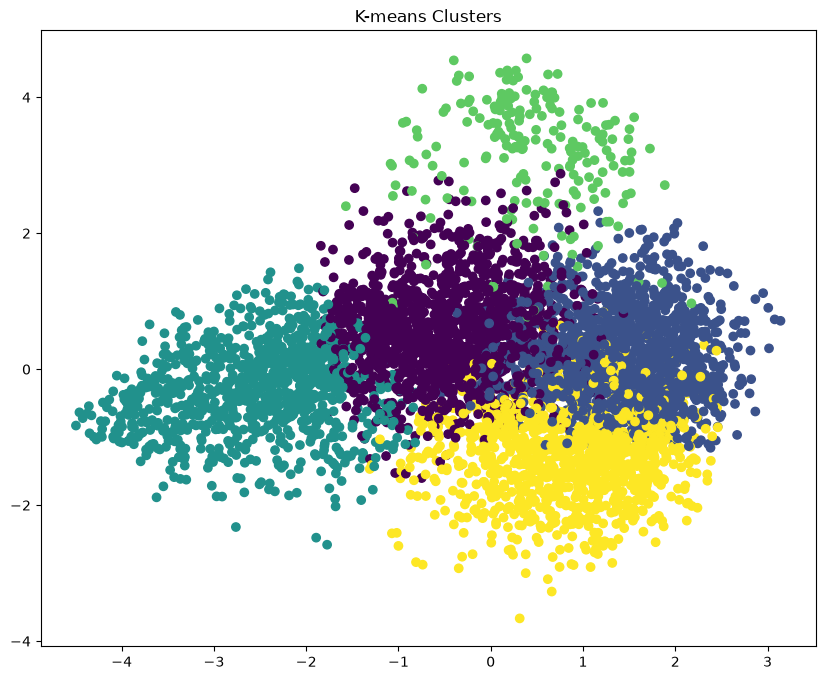

In [8]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

pca_result=pca.fit_transform(df_scaled)


plt.figure(figsize=(10,8))
plt.scatter(
    pca_result[:,0],   # X-axis
    pca_result[:,1],   # Y-axis
    c=df['Cluster'],
    cmap='viridis'
)

plt.title("K-means Clusters")
plt.show()

In [9]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

pca = PCA(n_components=2)
X_pca = pca.fit_transform(df_scaled)

kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
labels = kmeans.fit_predict(X_pca)

score = silhouette_score(X_pca, labels)

print("Silhouette Score:", score)

Silhouette Score: 0.4278434929741345


In [10]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

numerical_features = [
    "valence",
    "danceability",
    "energy",
    "tempo",
    "acousticness",
    "liveness",
    "speechiness",
    "instrumentalness"
]

def recommend_songs(song_name, df, num_recommendations=5):

    # Check if song exists
    if song_name not in df['name'].values:
        return "Song not found!"

    # Get cluster of the selected song
    song_cluster = df[df['name'] == song_name]['Cluster'].values[0]

    # Filter songs in same cluster and reset index
    same_cluster_songs = df[df['Cluster'] == song_cluster].reset_index(drop=True)

    # Find song index within the cluster
    song_index = same_cluster_songs[
        same_cluster_songs['name'] == song_name
    ].index[0]

    # Features for similarity
    cluster_features = same_cluster_songs[numerical_features]

    # Cosine similarity
    similarity = cosine_similarity(cluster_features)

    # Get similar songs
    similar_indices = np.argsort(
        similarity[song_index]
    )[-(num_recommendations + 1):-1][::-1]

    # Return recommendations
    recommendations = same_cluster_songs.iloc[
        similar_indices
    ][['name', 'year', 'artists']]

    return recommendations

In [11]:
input_song="Camby Bolongo"
recommended_songs=recommend_songs(input_song,df,num_recommendations=5)
print(f"Songs similar to '{input_song}':")
recommended_songs

Songs similar to 'Camby Bolongo':


,name,year,artists
954,Bitch to the Boys,1982,['Shakatak']
835,Chella llà - Instrument and base Version,1942,['Orchestra Studio 7']
1342,Danse Fambeaux,1968,['Dr. John']
867,"Aragon - From The ""Coffy"" Soundtrack",1973,['Roy Ayers']
167,Into Black,2011,['Blouse']


In [12]:
df.to_csv("clustered_df.csv")